Cell 1 — Import and load

In [1]:
import pandas as pd
df = pd.read_csv("earthquake_1995-2023.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


Cell 2 — Information

In [3]:
import pandas as pd
df = pd.read_csv("earthquake_1995-2023.csv")
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), obj

Cell 3 — Duplicate detection

In [4]:
# Count fully identical duplicate rows
full_duplicates = df.duplicated().sum()

print("Number of fully identical duplicate rows:", full_duplicates)

Number of fully identical duplicate rows: 0


In [5]:
# Count duplicate earthquakes using title and date_time
key_duplicates = df.duplicated(
    subset=["title", "date_time"]
).sum()

print("Duplicate earthquakes based on title + date_time:", key_duplicates)

Duplicate earthquakes based on title + date_time: 2


Cell 4 — Display meaningful duplicates

In [6]:
duplicate_records = df[
    df.duplicated(subset=["title", "date_time"], keep=False)
]

print("Duplicate earthquake records:")
display(duplicate_records)

Duplicate earthquake records:


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
67,"M 6.5 - 71 km SE of Nikolski, Alaska",6.5,11-01-2022 12:39,0,3,NaN,1,650,at,97,1.616070,108.0,Mi,37.0,52.502,-168.080,"Nikolski, Alaska",NaN,NaN
68,"M 6.5 - 71 km SE of Nikolski, Alaska",6.5,11-01-2022 12:39,0,3,NaN,1,650,pt,23,0.000000,208.8,Mi,37.0,52.502,-168.080,"Nikolski, Alaska",NaN,NaN
70,"M 6.7 - 91 km SE of Nikolski, Alaska",6.7,11-01-2022 11:35,0,4,NaN,1,691,at,50,0.936943,126.0,Mi,33.0,52.480,-167.736,"Nikolski, Alaska",NaN,NaN
71,"M 6.7 - 91 km SE of Nikolski, Alaska",6.7,11-01-2022 11:35,0,4,NaN,1,691,pt,20,0.000000,205.2,Mi,33.0,52.480,-167.736,"Nikolski, Alaska",NaN,NaN


Cell 5 — Remove duplicates

In [7]:
rows_before = len(df)

# Remove duplicate earthquakes
df = df.drop_duplicates(
    subset=["title", "date_time"],
    keep="first"
)

rows_after = len(df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before duplicate removal: 1000
Rows after duplicate removal: 998
Rows removed: 2


# Task 2 — Missing Values and Mean-vs-Median Imputation

Cell 6 — Missing report

In [8]:
# Missing value count
missing_count = df.isnull().sum()

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create missing-value report
missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("Missing Value Report:")
display(missing_report)

Missing Value Report:


,Missing Count,Missing Percentage
title,0,0.000000
magnitude,0,0.000000
date_time,0,0.000000
cdi,0,0.000000
mmi,0,0.000000
alert,549,55.010020
tsunami,0,0.000000
sig,0,0.000000
net,0,0.000000
nst,0,0.000000


Cell 7 — Zero placeholders

In [9]:
# Check zero values in columns where 0 represents missing/not measured
zero_columns = ["cdi", "gap", "nst", "dmin"]

for column in zero_columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

cdi: 395 zero values
gap: 252 zero values
nst: 519 zero values
dmin: 586 zero values


Cell 8 — Convert zero → NaN

In [11]:
import numpy as np

zero_columns = ["cdi", "gap", "nst", "dmin"]

for column in zero_columns:
    df[column] = df[column].replace(0, np.nan)

print("Zero placeholders converted to NaN.")

Zero placeholders converted to NaN.


In [12]:
print(df[zero_columns].isnull().sum())


cdi     395
gap     252
nst     519
dmin    586
dtype: int64


Cell 9 — Histograms

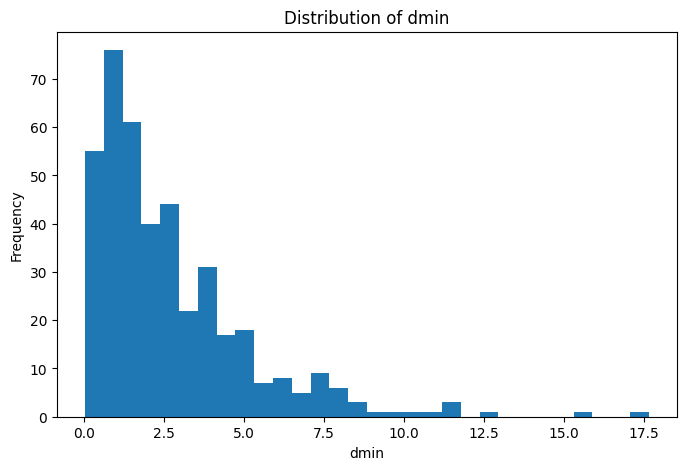

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["dmin"].dropna(), bins=30)

plt.title("Distribution of dmin")
plt.xlabel("dmin")
plt.ylabel("Frequency")

plt.show()

In [14]:
print("Skewness of dmin:", df["dmin"].skew())


Skewness of dmin: 1.9997583308140012


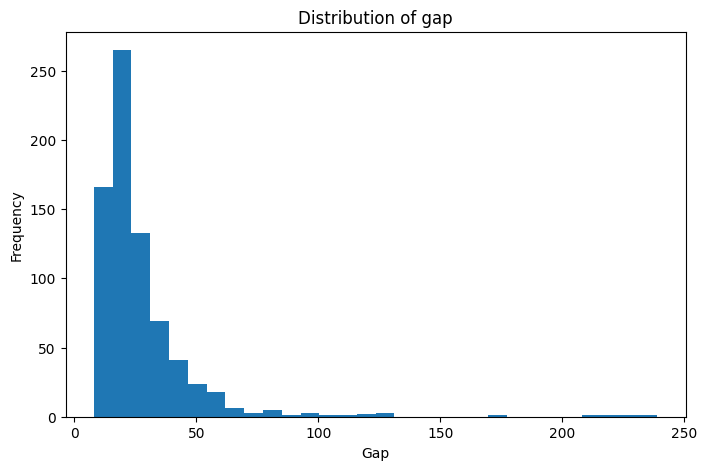

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["gap"].dropna(), bins=30)

plt.title("Distribution of gap")
plt.xlabel("Gap")
plt.ylabel("Frequency")

plt.show()

In [16]:
print("Skewness of gap:", df["gap"].skew())

Skewness of gap: 4.885701324053703


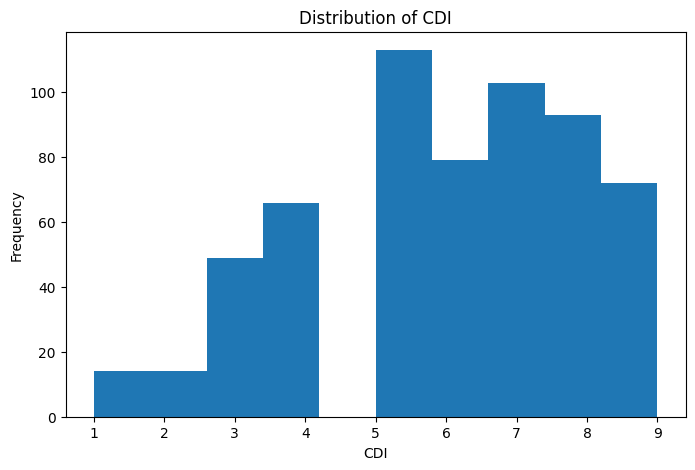

Skewness of cdi: -0.32333961422130675


In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df["cdi"].dropna(), bins=10)

plt.title("Distribution of CDI")
plt.xlabel("CDI")
plt.ylabel("Frequency")

plt.show()

print("Skewness of cdi:", df["cdi"].skew())

Cell 10 — Analyze distributions

In [18]:
columns_to_analyze = ["cdi", "dmin", "gap"]

for column in columns_to_analyze:
    print(f"\n{column}")
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Skewness:", df[column].skew())


cdi
Mean: 5.978441127694859
Median: 6.0
Skewness: -0.32333961422130675

dmin
Mean: 2.7310060048543687
Median: 1.9915
Skewness: 1.9997583308140012

gap
Mean: 27.4963672922252
Median: 21.25
Skewness: 4.885701324053703


Cell 11 — Imputation

In [19]:
df["cdi"] = df["cdi"].fillna(df["cdi"].mean())

In [20]:
df["dmin"] = df["dmin"].fillna(df["dmin"].median())

In [21]:
df["gap"] = df["gap"].fillna(df["gap"].median())

In [22]:
df["nst"] = df["nst"].fillna(df["nst"].median())

Cell 12 — Categorical values

In [23]:
df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

In [28]:
df["location"] = df["location"].fillna("Unknown")
df["continent"] = df["continent"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

Cell 13 — Final verification

In [29]:
final_missing = df.isnull().sum()

print("Final missing values:")
display(final_missing)

Final missing values:


title        0
magnitude    0
date_time    0
cdi          0
mmi          0
alert        0
tsunami      0
sig          0
net          0
nst          0
dmin         0
gap          0
magType      0
depth        0
latitude     0
longitude    0
location     0
continent    0
country      0
dtype: int64

In [30]:
print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


Cell 14 — Final visualization

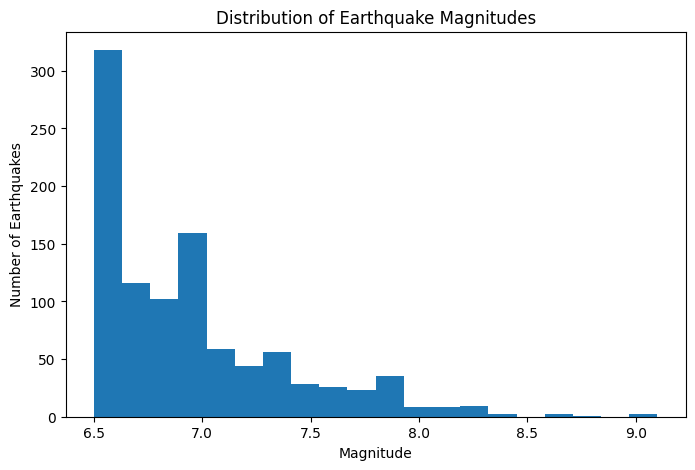

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(df["magnitude"], bins=20)

plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.show()

Cell 15 — Alert visualization

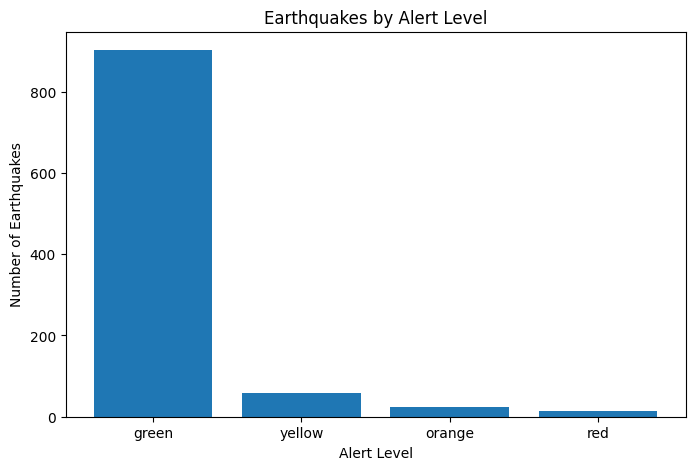

In [32]:
alert_counts = df["alert"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(alert_counts.index, alert_counts.values)

plt.title("Earthquakes by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Number of Earthquakes")

plt.show()

In [33]:
df_before_imputation = df.copy()

In [34]:
before_dmin = df["dmin"].dropna()

In [35]:
after_dmin = df["dmin"]

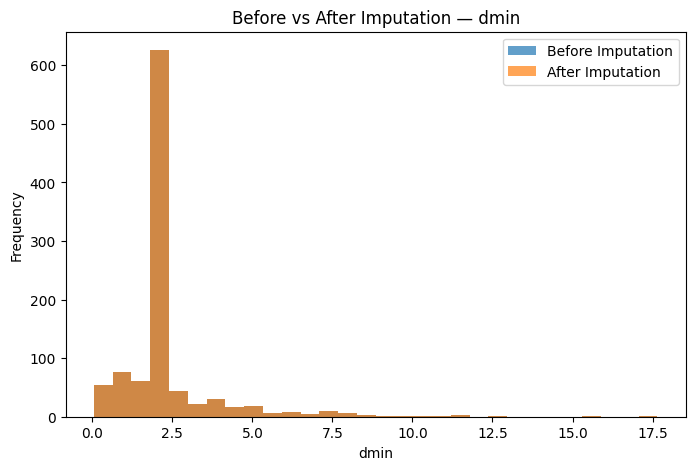

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(before_dmin, bins=30, alpha=0.7, label="Before Imputation")
plt.hist(after_dmin, bins=30, alpha=0.7, label="After Imputation")

plt.title("Before vs After Imputation — dmin")
plt.xlabel("dmin")
plt.ylabel("Frequency")

plt.legend()
plt.show()

* cleaning decisions

cdi

Decision: Mean

The CDI distribution is relatively close to symmetric, with skewness near zero. Therefore, mean imputation is appropriate because the mean is not strongly distorted by skewness or extreme values.

dmin

Decision: Median

The dmin distribution is positively skewed, with a skewness of approximately 2.0. Because extreme values can pull the mean upward, median imputation is more robust.

gap

Decision: Median

The gap distribution is highly positively skewed, with a skewness of approximately 4.88. Therefore, the median is preferred because it is less sensitive to extreme observations.